In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.special as sp
from mpl_toolkits.basemap import Basemap
from matplotlib.colors import ListedColormap
import matplotlib.cm as cm

from sklearn.neighbors import NearestNeighbors
import pickle

In [2]:
from Utility_fun import sph2cart, cart2sph
from DirMS_fun import DirKDE, MS_DirKDE
import ray

In [3]:
@ray.remote
def DirMS_Ray(y_0, data, h=None, eps=1e-7, max_iter=1000, wt=None, diff_method='all', trunc_ind=False):
    '''
    Directional mean shift algorithm with the von-Mises Kernel
    
    Parameters:
        y_0: (N,d)-array
            The Euclidean coordinates of N directional initial points in 
            d-dimensional Euclidean space.
    
        data: (n,d)-array
            The Euclidean coordinates of n directional random sample points in 
            d-dimensional Euclidean space.
       
        h: float
            The bandwidth parameter. (Default: h=None. Then a rule of thumb for 
            directional KDEs with the von Mises kernel in Garcia-Portugues (2013)
            is applied.)
        
        eps: float
            The precision parameter for stopping the mean shift iteration.
            (Default: eps=1e-7)
        
        max_iter: int
            The maximum number of iterations for the mean shift iteration.
            (Default: max_iter=1000)
            
        wt: (n,)-array
            The weights of kernel density contributions for n directional random 
            sample points. (Default: wt=None, that is, each data point has the 
            weight "1/n".)
            
        diff_method: str ('all'/'mean')
            The method of computing the differences between two consecutive sets
            of iteration points when they are compared with the precision 
            parameter to stop the algorithm. (When diff_method='all', all the 
            differences between two consecutive sets of iteration points need 
            to be smaller than 'eps' for terminating the algorithm. When 
            diff_method='mean', only the mean difference is compared with 'eps'
            and stop the algorithm. Default: diff_method='all'.)
    
    Return:
        MS_new: (m,d)-array
            The collection of converged points yielded by the DMS algorithm.
    '''

    n = data.shape[0]  ## Number of data points
    d = data.shape[1]  ## Euclidean dimension of the data

    ## Rule of thumb for directional KDE
    if h is None:
        R_bar = np.sqrt(sum(np.mean(data, axis=0) ** 2))
        ## An approximation to kappa (Banerjee 2005 & Sra, 2011)
        kap_hat = R_bar * (d - R_bar ** 2) / (1 - R_bar ** 2)
        if d == 3:
            h = (8*np.sinh(kap_hat)**2/(n*kap_hat * \
                 ((1+4*kap_hat**2)*np.sinh(2*kap_hat) - \
                  2*kap_hat*np.cosh(2*kap_hat))))**(1/6)
        else:
            h = ((4 * np.sqrt(np.pi) * sp.iv(d / 2 - 1, kap_hat)**2) / \
                 (n * kap_hat ** (d / 2) * (2 * (d - 1) * sp.iv(d/2, 2*kap_hat) + \
                                  (d+1) * kap_hat * sp.iv(d/2+1, 2*kap_hat)))) ** (1/(d + 3))
        print("The current bandwidth is " + str(h) + ".\n")

    MS_new = np.copy(y_0)
    mask = np.arange(y_0.shape[0])
    ind = np.zeros((y_0.shape[0], ))
    if wt is None:
        wt = np.ones((n,))
    for t in range(1, max_iter):
        # y_can = np.dot(np.exp(np.dot(MS_path[:,:,t-1], data.T/(h**2))), data)
        MS_old = np.copy(MS_new)
        y_can = np.dot(np.exp((np.dot(MS_old, data.T)-1)/(h**2)), data * wt.reshape(n,1))
        y_dist = np.sqrt(np.sum(y_can ** 2, axis=1))
        ind[mask] += (y_dist == 0)
        mask = mask[y_dist != 0]
        y_can = y_can[y_dist != 0,:]
        y_dist = y_dist[y_dist != 0]
        MS_new = y_can / y_dist.reshape(len(y_dist), 1)
        if diff_method == 'mean' and np.mean(1- np.diagonal(np.dot(MS_new, MS_old.T))) <=eps:
            break
        elif all(1 - np.diagonal(np.dot(MS_new, MS_old.T)) <= eps):
            break       
    '''
    if t < max_iter:
        print('The directional mean shift algorithm converges in ' + str(t) + ' steps!')
    else:
        print('The directional mean shift algorithm reaches the maximum number '\
              'of iterations,' + str(max_iter) + ' and has not yet converged.')
    '''
    if trunc_ind:
        return MS_new, ind
    else:
        return MS_new

In [4]:
def Unique_Modes(can_modes, tol=1e-4):
    '''
    A helper function: Group the output mesh points from mode-seeking algorithm into distinct modes and output mode clustering labels.
    @ Parameter:
        can_modes -- The output mesh points from any mode-seeking algorithm
        tol -- Tolerance for pairwise distances between mesh points (Any pair of mesh points with distance less than this value will be grouped into the same cluster).
    @ Return: 
        1) A numpy array with the coordinates of distinct modes; 
        2) A 1-dim array with integer labels and length N for specifying the affiliation of each mesh point (N is the number of rows in 'modes').
    '''
    n_modes = can_modes.shape[0]   ## The number of candidate modes
    d = can_modes.shape[1]    ## The dimension of (candidate) modes
    modes_ind = [0]   ## Candidate list of unique modes
    labels = np.empty([n_modes, ], dtype=int)
    labels[0] = 0
    curr_lb = 0   ## The current label indicator
    
    for i in range(1, n_modes):
        flag = None   ## Indicate whether index i should be added to the candidate list of unique modes
        for j in modes_ind:
            if 1-np.dot(can_modes[i,:].reshape(1,d), can_modes[j,:].reshape(d,1)) <= tol:
                flag = labels[j]  # The mode has been existing
        if flag is None:
            curr_lb += 1
            modes_ind.append(i)
            labels[i] = curr_lb
        else:
            labels[i] = flag
    
    return can_modes[modes_ind,:], labels

### Load the SDSS Galaxy Data

In [5]:
# gal_slice = SDSS_dat[((SDSS_dat.Z >= 0.05) & (SDSS_dat.Z < 0.06)) | ((SDSS_dat.Z >= 0.5) & (SDSS_dat.Z < 0.51)) | ((SDSS_dat.Z >= 1) & (SDSS_dat.Z < 1.01))]
# gal_slice.to_csv('SDSSIV_gal_dat.csv', index=False)

In [6]:
SDSS_dat = pd.read_csv('Data/SDSSIV_gal_dat.csv')
SDSS_dat.head(5)

,PLATE,MJD,FIBERID,RA,DEC,Z,total_mass,class,comov_dist
0,266,51602,6,146.96390,-0.545003,0.055988,3.357219e+07,GALAXY,244.532677
1,266,51602,16,146.63167,-0.988278,0.052659,2.034939e+09,GALAXY,230.175408
2,266,51602,63,146.78847,-0.310658,0.056610,5.353840e+08,GALAXY,247.213100
3,266,51602,69,146.90125,-0.413157,0.056576,1.989365e+10,GALAXY,247.066313
4,266,51602,112,146.72901,0.026972,0.056704,1.263112e+10,GALAXY,247.617629


### Redshift slice: $0.05\leq z < 0.055$

We remove those galaxies without estimated stellar masses in this redshift slice and apply the directional mean shift (DMS) algorithm to this dataset.

In [7]:
z_l = 0.05
z_h = 0.055
gal_slice = SDSS_dat[(SDSS_dat.Z >= z_l) & (SDSS_dat.Z < z_h)]
# Focus on the north galactic cap
gal_north = gal_slice[(gal_slice.RA > 100) & (gal_slice.RA < 270) & (gal_slice.DEC > -5) & (gal_slice.DEC < 70)]
# Remove those galaxies without estimated stellar mass
gal_north1 = gal_north[gal_north.total_mass != -9999]
print(1 - gal_north1.shape[0]/gal_north.shape[0])
X, Y, Z = sph2cart(*gal_north1[['RA', 'DEC']].values.T)
gal_north_cart = np.concatenate([X.reshape(-1,1), Y.reshape(-1,1), Z.reshape(-1,1)], axis=1)
gal_north_ang = gal_north1[['RA', 'DEC']].values
print(gal_north_cart.shape)

0.07679774538729134
(20965, 3)


In [8]:
# Bandwidth selection
data = gal_north_cart
d = data.shape[1]
n = data.shape[0]
R_bar = np.sqrt(sum(np.mean(data, axis=0) ** 2))
kap_hat = R_bar * (d - R_bar ** 2) / (1 - R_bar ** 2)
h = (8*np.sinh(kap_hat)**2/(n*kap_hat * \
             ((1+4*kap_hat**2)*np.sinh(2*kap_hat) - 2*kap_hat*np.cosh(2*kap_hat))))**(1/6)
bw_Dir = h/3

# Data denoising
d_Dir_dat = DirKDE(gal_north_cart, gal_north_cart, h=bw_Dir)
gal_cart_thres = gal_north_cart[d_Dir_dat >= np.std(d_Dir_dat)]
if gal_cart_thres.shape[0]/gal_north_cart.shape[0] < 0.9:
    gal_cart_thres = gal_north_cart[d_Dir_dat >= np.quantile(d_Dir_dat, 0.1)]
print("Directional Thresholding Ratio: "+str(gal_cart_thres.shape[0]/gal_north_cart.shape[0]))

nrows, ncols = (76, 171)
lon_m1, lat_m1 = np.meshgrid(np.linspace(100, 270, ncols), np.linspace(-5, 70, nrows))
xg, yg, zg = sph2cart(lon_m1, lat_m1)

mesh1 = np.concatenate((xg.reshape(nrows*ncols, 1),
                        yg.reshape(nrows*ncols, 1),
                        zg.reshape(nrows*ncols, 1)), axis=1)

Directional Thresholding Ratio: 0.8999761507274028


In [9]:
ray.init()
mesh_0 = mesh1
dataset = gal_cart_thres
BW = bw_Dir
chunksize = 10
num_p = mesh_0.shape[0]
result_ids = []
for i in range(0, num_p, chunksize):
    result_ids.append(DirMS_Ray.remote(mesh_0[i:(i+chunksize)], dataset, h=BW, eps=1e-9, max_iter=5000, 
                                       trunc_ind=True))
results = ray.get(result_ids)
DirMS_pts_list, trunc_ind_list = zip(*results)

# Concatenate separately
DirMS_pts = np.concatenate(DirMS_pts_list, axis=0)
trunc_pts = np.concatenate(trunc_ind_list, axis=0)
ray.shutdown()


ray.init()
mesh_0 = gal_north_cart
dataset = gal_cart_thres
BW = bw_Dir
chunksize = 10
num_p = mesh_0.shape[0]
result_ids = []
for i in range(0, num_p, chunksize):
    result_ids.append(DirMS_Ray.remote(mesh_0[i:(i+chunksize)], dataset, h=BW, eps=1e-9, max_iter=5000))
DirMS_gal = ray.get(result_ids)
DirMS_gal = np.concatenate(DirMS_gal, axis=0)
ray.shutdown()

with open("./Results/DMS_z"+str(round(z_l, 3))+"_"+str(round(z_h, 3))+"_obs3.dat", "wb") as file:
    pickle.dump([bw_Dir, DirMS_pts, trunc_pts, DirMS_gal], file)

2026-02-23 11:03:43,764	INFO worker.py:1529 -- Started a local Ray instance. View the dashboard at 127.0.0.1:8265 


### Redshift slice: $0.5\leq z < 0.505$

We remove those galaxies without estimated stellar masses in this redshift slice and apply the directional mean shift (DMS) algorithm to this dataset.

In [9]:
z_l = 0.5
z_h = 0.505
gal_slice = SDSS_dat[(SDSS_dat.Z >= z_l) & (SDSS_dat.Z < z_h)]
# Focus on the north galactic cap
gal_north = gal_slice[(gal_slice.RA > 100) & (gal_slice.RA < 270) & (gal_slice.DEC > -5) & (gal_slice.DEC < 70)]
# Remove those galaxies without estimated stellar mass
gal_north1 = gal_north[gal_north.total_mass != -9999]
print(1 - gal_north1.shape[0]/gal_north.shape[0])
X, Y, Z = sph2cart(*gal_north1[['RA', 'DEC']].values.T)
gal_north_cart = np.concatenate([X.reshape(-1,1), Y.reshape(-1,1), Z.reshape(-1,1)], axis=1)
gal_north_ang = gal_north1[['RA', 'DEC']].values
print(gal_north_cart.shape)

0.4042870905587669
(12367, 3)


In [10]:
# Bandwidth selection
data = gal_north_cart
d = data.shape[1]
n = data.shape[0]
R_bar = np.sqrt(sum(np.mean(data, axis=0) ** 2))
kap_hat = R_bar * (d - R_bar ** 2) / (1 - R_bar ** 2)
h = (8*np.sinh(kap_hat)**2/(n*kap_hat * \
             ((1+4*kap_hat**2)*np.sinh(2*kap_hat) - 2*kap_hat*np.cosh(2*kap_hat))))**(1/6)
bw_Dir = h/3

# Data denoising
d_Dir_dat = DirKDE(gal_north_cart, gal_north_cart, h=bw_Dir)
gal_cart_thres = gal_north_cart[d_Dir_dat >= np.std(d_Dir_dat)]
if gal_cart_thres.shape[0]/gal_north_cart.shape[0] < 0.9:
    gal_cart_thres = gal_north_cart[d_Dir_dat >= np.quantile(d_Dir_dat, 0.1)]
print("Directional Thresholding Ratio: "+str(gal_cart_thres.shape[0]/gal_north_cart.shape[0]))

nrows, ncols = (76, 171)
lon_m1, lat_m1 = np.meshgrid(np.linspace(100, 270, ncols), np.linspace(-5, 70, nrows))
xg, yg, zg = sph2cart(lon_m1, lat_m1)

mesh1 = np.concatenate((xg.reshape(nrows*ncols, 1),
                        yg.reshape(nrows*ncols, 1),
                        zg.reshape(nrows*ncols, 1)), axis=1)

Directional Thresholding Ratio: 0.9176032991024501


In [12]:
ray.init()
mesh_0 = mesh1
dataset = gal_cart_thres
BW = bw_Dir
chunksize = 10
num_p = mesh_0.shape[0]
result_ids = []
for i in range(0, num_p, chunksize):
    result_ids.append(DirMS_Ray.remote(mesh_0[i:(i+chunksize)], dataset, h=BW, eps=1e-9, max_iter=5000, 
                                       trunc_ind=True))
results = ray.get(result_ids)
DirMS_pts_list, trunc_ind_list = zip(*results)

# Concatenate separately
DirMS_pts = np.concatenate(DirMS_pts_list, axis=0)
trunc_pts = np.concatenate(trunc_ind_list, axis=0)
ray.shutdown()

# with open("./Theory_Method_Results/SDSS_Data/DMS_z"+str(round(z_l, 3))+"_"+str(round(z_h, 3))+"_obs3.dat", "rb") as file:
#     bw_Dir, DirMS_pts, trunc_pts = pickle.load(file)

ray.init()
mesh_0 = gal_north_cart
dataset = gal_cart_thres
BW = bw_Dir
chunksize = 10
num_p = mesh_0.shape[0]
result_ids = []
for i in range(0, num_p, chunksize):
    result_ids.append(DirMS_Ray.remote(mesh_0[i:(i+chunksize)], dataset, h=BW, eps=1e-9, max_iter=5000))
DirMS_gal = ray.get(result_ids)
DirMS_gal = np.concatenate(DirMS_gal, axis=0)
ray.shutdown()

with open("./Results/DMS_z"+str(round(z_l, 3))+"_"+str(round(z_h, 3))+"_obs3.dat", "wb") as file:
    pickle.dump([bw_Dir, DirMS_pts, trunc_pts, DirMS_gal], file)

2026-02-23 12:02:30,292	INFO worker.py:1529 -- Started a local Ray instance. View the dashboard at 127.0.0.1:8265 


In [14]:
ray.shutdown()

### Redshift slice: $1\leq z < 1.005$

We remove those galaxies without estimated stellar masses in this redshift slice and apply the directional mean shift (DMS) algorithm to this dataset.

In [12]:
z_l = 1
z_h = 1.005
gal_slice = SDSS_dat[(SDSS_dat.Z >= z_l) & (SDSS_dat.Z < z_h)]
# Focus on the north galactic cap
gal_north = gal_slice[(gal_slice.RA > 100) & (gal_slice.RA < 270) & (gal_slice.DEC > -5) & (gal_slice.DEC < 70)]
# Remove those galaxies without estimated stellar mass
gal_north1 = gal_north[gal_north.total_mass != -9999]
print(1 - gal_north1.shape[0]/gal_north.shape[0])
X, Y, Z = sph2cart(*gal_north1[['RA', 'DEC']].values.T)
gal_north_cart = np.concatenate([X.reshape(-1,1), Y.reshape(-1,1), Z.reshape(-1,1)], axis=1)
gal_north_ang = gal_north1[['RA', 'DEC']].values
print(gal_north_cart.shape)

0.5473646723646723
(1271, 3)


In [13]:
# Bandwidth selection
data = gal_north_cart
d = data.shape[1]
n = data.shape[0]
R_bar = np.sqrt(sum(np.mean(data, axis=0) ** 2))
kap_hat = R_bar * (d - R_bar ** 2) / (1 - R_bar ** 2)
h = (8*np.sinh(kap_hat)**2/(n*kap_hat * \
             ((1+4*kap_hat**2)*np.sinh(2*kap_hat) - 2*kap_hat*np.cosh(2*kap_hat))))**(1/6)
bw_Dir = h/3

# Data denoising
d_Dir_dat = DirKDE(gal_north_cart, gal_north_cart, h=bw_Dir)
gal_cart_thres = gal_north_cart[d_Dir_dat >= np.std(d_Dir_dat)]
if gal_cart_thres.shape[0]/gal_north_cart.shape[0] < 0.9:
    gal_cart_thres = gal_north_cart[d_Dir_dat >= np.quantile(d_Dir_dat, 0.1)]
print("Directional Thresholding Ratio: "+str(gal_cart_thres.shape[0]/gal_north_cart.shape[0]))

nrows, ncols = (76, 171)
lon_m1, lat_m1 = np.meshgrid(np.linspace(100, 270, ncols), np.linspace(-5, 70, nrows))
xg, yg, zg = sph2cart(lon_m1, lat_m1)

mesh1 = np.concatenate((xg.reshape(nrows*ncols, 1),
                        yg.reshape(nrows*ncols, 1),
                        zg.reshape(nrows*ncols, 1)), axis=1)

Directional Thresholding Ratio: 0.9000786782061369


In [14]:
ray.init()
mesh_0 = mesh1
dataset = gal_cart_thres
BW = bw_Dir
chunksize = 10
num_p = mesh_0.shape[0]
result_ids = []
for i in range(0, num_p, chunksize):
    result_ids.append(DirMS_Ray.remote(mesh_0[i:(i+chunksize)], dataset, h=BW, eps=1e-9, max_iter=5000, 
                                       trunc_ind=True))
results = ray.get(result_ids)
DirMS_pts_list, trunc_ind_list = zip(*results)

# Concatenate separately
DirMS_pts = np.concatenate(DirMS_pts_list, axis=0)
trunc_pts = np.concatenate(trunc_ind_list, axis=0)
ray.shutdown()

ray.init()
mesh_0 = gal_north_cart
dataset = gal_cart_thres
BW = bw_Dir
chunksize = 10
num_p = mesh_0.shape[0]
result_ids = []
for i in range(0, num_p, chunksize):
    result_ids.append(DirMS_Ray.remote(mesh_0[i:(i+chunksize)], dataset, h=BW, eps=1e-9, max_iter=5000))
DirMS_gal = ray.get(result_ids)
DirMS_gal = np.concatenate(DirMS_gal, axis=0)
ray.shutdown()

with open("./Results/DMS_z"+str(round(z_l, 3))+"_"+str(round(z_h, 3))+"_obs3.dat", "wb") as file:
    pickle.dump([bw_Dir, DirMS_pts, trunc_pts, DirMS_gal], file)

2026-03-05 16:43:54,262	INFO worker.py:2013 -- Started a local Ray instance.
2026-03-05 16:44:03,489	INFO worker.py:2013 -- Started a local Ray instance.


In [15]:
with open("./Results/DMS_z"+str(round(z_l, 3))+"_"+str(round(z_h, 3))+"_obs3.dat", "rb") as file:
    bw_Dir, DirMS_pts, trunc_pts, DirMS_gal = pickle.load(file)

uni_m, uni_m_lab = Unique_Modes(can_modes=DirMS_pts, tol=1e-3)

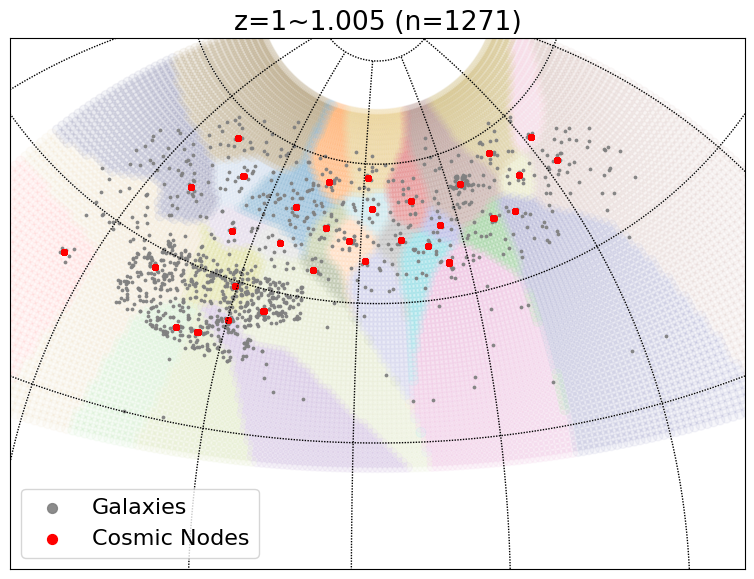

In [17]:
plt.rcParams.update({'font.size': 16})  ## Change the font sizes of ouput figures
fig = plt.figure(figsize=(8,6))

lon_g = gal_north_ang[:,0]
lat_g = gal_north_ang[:,1]
lon_m, lat_m, R = cart2sph(*DirMS_pts.T)
lon_m[(lon_m >= -180) & (lon_m <= 0)] = lon_m[(lon_m >= -180) & (lon_m <= 0)] + 360
lon_p, lat_p, R = cart2sph(*mesh1[trunc_pts == 0].T)
lon_p[(lon_p >= -180) & (lon_p <= 0)] = lon_p[(lon_p >= -180) & (lon_p <= 0)] + 360

labels = np.unique(uni_m_lab)
n_cat = len(labels)
cmaps = [plt.cm.tab20, plt.cm.tab20b, plt.cm.tab20c]
colors = np.vstack([cmap(np.linspace(0,1,20)) for cmap in cmaps])
colors = colors[:n_cat]
np.random.seed(123)
np.random.shuffle(colors)
cmap = ListedColormap(colors)

# m1 = Basemap(projection='npaeqd', boundinglat=20, lon_0=0, resolution='l')
m1 = Basemap(width=18000000, height=13000000, resolution='l', projection='stere', lat_ts=50, lat_0=30, lon_0=185)
m1.drawmeridians(np.arange(0, 360, 30))
m1.drawparallels(np.arange(-90, 90, 30))
x_g, y_g = m1(lon_g, lat_g)
x_m, y_m = m1(lon_m, lat_m)
x_p, y_p = m1(lon_p, lat_p)
cs = m1.scatter(x_p, y_p, c=uni_m_lab, cmap=cmap, marker='o', s=50, alpha=0.05)
cs = m1.scatter(x_g, y_g, color='grey', marker='o', s=3, alpha=0.9, label='Galaxies')
cs = m1.scatter(x_m, y_m, color='red', marker='o', s=15, label='Cosmic Nodes')

lgnd = plt.legend(loc='lower left', numpoints=1)
# change the marker size manually for both lines
lgnd.legend_handles[0]._sizes = [50]
lgnd.legend_handles[1]._sizes = [50]
# lgnd.legendHandles[2]._sizes = [50]
plt.title('z='+str(round(z_l, 3))+'~'+str(round(z_h, 3))+' (n='+str(gal_north_cart.shape[0])+')')
plt.tight_layout()
plt.show()

### Visualization of Basins of Attraction

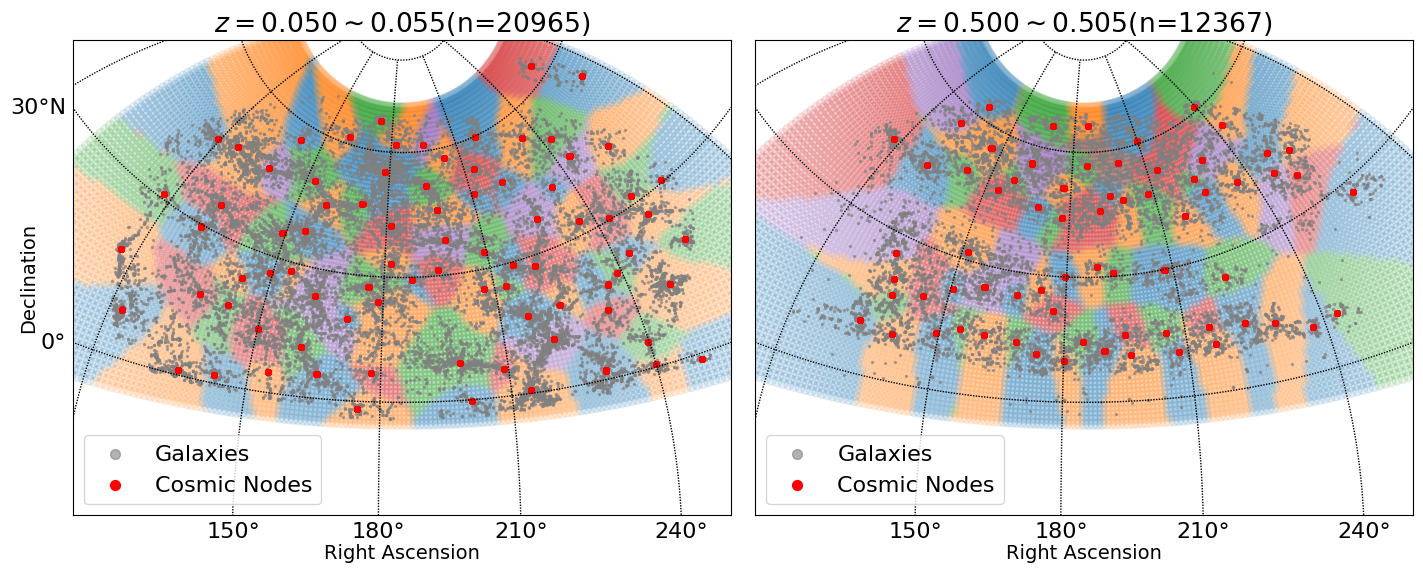

In [18]:
plt.rcParams.update({'font.size': 16})

fig, axes = plt.subplots(1, 2, figsize=(14.5, 6.5)) 

z_pairs = [(0.05, 0.055),
           (0.5, 0.505)]

for ax, (z_l, z_h) in zip(axes, z_pairs):
    # --- Data slice ---
    gal_slice = SDSS_dat[(SDSS_dat.Z >= z_l) & (SDSS_dat.Z < z_h)]
    gal_north = gal_slice[(gal_slice.RA > 100) & (gal_slice.RA < 270) &
                          (gal_slice.DEC > -5) & (gal_slice.DEC < 70)]
    gal_north1 = gal_north[gal_north.total_mass != -9999]

    X, Y, Z = sph2cart(*gal_north1[['RA', 'DEC']].values.T)
    gal_north_cart = np.column_stack([X, Y, Z])
    gal_north_ang = gal_north1[['RA', 'DEC']].values

    # --- Load directional MS results ---
    with open(f"./Results/DMS_z{round(z_l,3)}_{round(z_h,3)}_obs3.dat", "rb") as file:
        bw_Dir, DirMS_pts, trunc_pts, DirMS_gal = pickle.load(file)

    uni_m, uni_m_lab = Unique_Modes(can_modes=DirMS_pts, tol=1e-4)

    lon_g = gal_north_ang[:,0]
    lat_g = gal_north_ang[:,1]

    lon_m, lat_m, _ = cart2sph(*DirMS_pts.T)
    lon_m[(lon_m >= -180) & (lon_m <= 0)] += 360

    lon_p, lat_p, _ = cart2sph(*mesh1[trunc_pts == 0].T)
    lon_p[(lon_p >= -180) & (lon_p <= 0)] += 360

    # --- Colormap ---
    pts = mesh1[trunc_pts == 0]
    labels = uni_m_lab

    # find neighbors
    nbrs = NearestNeighbors(n_neighbors=8).fit(pts)
    indices = nbrs.kneighbors(return_distance=False)

    # build adjacency dictionary
    adj = {i: set() for i in np.unique(labels)}

    for i, neigh in enumerate(indices):
        for j in neigh:
            if labels[i] != labels[j]:
                adj[labels[i]].add(labels[j])
                adj[labels[j]].add(labels[i])
    
    color_assignment = {}
    available_colors = list(range(100))  # large enough pool

    for node in adj:
        used = {color_assignment[n] for n in adj[node] if n in color_assignment}
        for c in available_colors:
            if c not in used:
                color_assignment[node] = c
                break
    
    n_used = max(color_assignment.values()) + 1

    base_colors = plt.cm.tab10(np.linspace(0,1,10))
    extra = plt.cm.tab20b(np.linspace(0,1,20))
    extra2 = plt.cm.tab20c(np.linspace(0,1,20))

    all_colors = np.vstack([base_colors, extra, extra2])

    final_colors = all_colors[:n_used]

    cmap = ListedColormap(final_colors)
    # remap labels
    new_labels = np.array([color_assignment[l] for l in uni_m_lab])

    # --- Basemap on specific axis ---
    m = Basemap(width=18000000, height=13000000, resolution='l', projection='stere', lat_ts=50, lat_0=30,
                lon_0=185, ax=ax)

    m.drawmeridians(np.arange(0, 360, 30), fmt=(lambda x: (u"%d\N{DEGREE SIGN}") % (x)), 
                    labels=[False,False,False,True])
    if z_l == 0.05:
        m.drawparallels(np.arange(-90, 90, 30), labels=[True,False,False,False])
    else:
        m.drawparallels(np.arange(-90, 90, 30))

    x_g, y_g = m(lon_g, lat_g)
    x_m, y_m = m(lon_m, lat_m)
    x_p, y_p = m(lon_p, lat_p)

    m.scatter(x_p, y_p, c=new_labels, cmap=cmap, marker='o', s=50, alpha=0.1)

    m.scatter(x_g, y_g, color='grey', marker='o', s=2, alpha=0.6, label='Galaxies')

    m.scatter(x_m, y_m, color='red', marker='o', s=15, label='Cosmic Nodes')

    ax.set_title(rf'$z ={z_l:.3f} \sim {z_h:.3f}$' + f'(n={gal_north_cart.shape[0]})')
    ax.set_xlabel('Right Ascension', labelpad=20, fontsize=14)
    if z_l == 0.05:
        ax.set_ylabel('Declination', labelpad=25, fontsize=14)
    
    lgnd = ax.legend(loc='lower left')
    lgnd.legend_handles[0]._sizes = [50]
    lgnd.legend_handles[1]._sizes = [50]

fig.tight_layout()
# plt.show()
fig.savefig('./Figures/SDSS_BOA.pdf')
# fig.savefig('./Figures/SDSS_BOA.jpg', bbox_inches="tight", dpi=300)

### Scatterplot of Average Stellar Mass Against Average Density Within Each Basin of Attraction

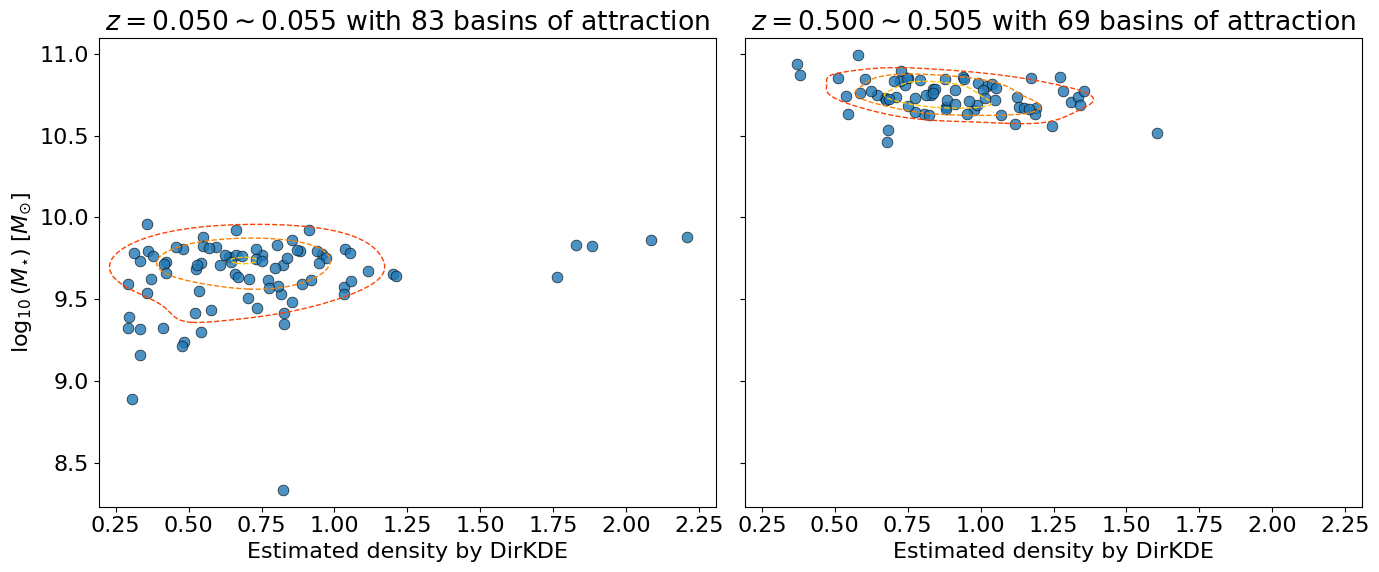

In [19]:
plt.rcParams.update({'font.size': 16})
from scipy.stats import gaussian_kde

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True, sharex=True) 

z_pairs = [(0.05, 0.055),
           (0.5, 0.505)]

for ax, (z_l, z_h) in zip(axes, z_pairs):
    # --- Data slice ---
    gal_slice = SDSS_dat[(SDSS_dat.Z >= z_l) & (SDSS_dat.Z < z_h)]
    gal_north = gal_slice[(gal_slice.RA > 100) & (gal_slice.RA < 270) &
                          (gal_slice.DEC > -5) & (gal_slice.DEC < 70)]
    gal_north1 = gal_north[gal_north.total_mass != -9999].copy()

    X, Y, Z = sph2cart(*gal_north1[['RA', 'DEC']].values.T)
    gal_north_cart = np.column_stack([X, Y, Z])
    gal_north_ang = gal_north1[['RA', 'DEC']].values
    
    # Bandwidth selection
    data = gal_north_cart
    d = data.shape[1]
    n = data.shape[0]
    R_bar = np.sqrt(sum(np.mean(data, axis=0) ** 2))
    kap_hat = R_bar * (d - R_bar ** 2) / (1 - R_bar ** 2)
    h = (8*np.sinh(kap_hat)**2/(n*kap_hat * \
                 ((1+4*kap_hat**2)*np.sinh(2*kap_hat) - 2*kap_hat*np.cosh(2*kap_hat))))**(1/6)
    bw_Dir = h/3

    # Density estimation
    d_Dir_dat = DirKDE(gal_north_cart, gal_north_cart, h=bw_Dir)
    gal_north1['density'] = d_Dir_dat / np.mean(d_Dir_dat)

    # --- Load directional MS results ---
    with open(f"./Results/DMS_z{round(z_l,3)}_{round(z_h,3)}_obs3.dat", "rb") as file:
        bw_Dir, DirMS_pts, trunc_pts, DirMS_gal = pickle.load(file)

    uni_m, uni_m_lab = Unique_Modes(can_modes=DirMS_gal, tol=1e-4)
    gal_north1['BOA'] = uni_m_lab
    gal_north1['log_tot_mass'] = np.log10(gal_north1['total_mass'])
    mass_den = gal_north1[['log_tot_mass', 'density', 'BOA']].groupby('BOA').mean().reset_index()
    
    counts = gal_north1.groupby('BOA').size().values
    mass_den['counts'] = counts

    ax.scatter(mass_den['density'], mass_den['log_tot_mass'], s=60, alpha=0.8, edgecolor='k', linewidth=0.5)
    
    # 2D KDE contour
    x = mass_den['density'].values
    y = mass_den['log_tot_mass'].values
    xy = np.vstack([x, y])
    kde = gaussian_kde(xy)

    x_grid = np.linspace(x.min()-0.1, x.max()+0.1, 100)
    y_grid = np.linspace(y.min()-0.1, y.max()+0.1, 100)
    X_grid, Y_grid = np.meshgrid(x_grid, y_grid)
    Z = kde(np.vstack([X_grid.ravel(), Y_grid.ravel()])).reshape(X_grid.shape)

    ax.contour(X_grid, Y_grid, Z, levels=3, linewidths=1, linestyles='dashed', cmap='autumn')
    
    ax.set_xlabel('Estimated density by DirKDE')
    if z_l == 0.05:
        ax.set_ylabel(r'$\log_{10}(M_{\star}) \; [M_{\odot}]$')
    ax.set_title(rf'$z ={z_l:.3f} \sim {z_h:.3f}$ with ' + f'{len(np.unique(uni_m_lab))} basins of attraction')
    # ax.grid(True, linestyle='--', alpha=0.4)

fig.tight_layout()
# plt.show()
fig.savefig('./Figures/BOA_mass_density.pdf')